<a href="https://colab.research.google.com/github/sarzara/Python-for-data-analysis/blob/main/OnlineRetailTransaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Consultancy Topic: Online Retail Transactions**

The goal is extracting insights that can support business decision-making, such as
identifying


*   Top-seller products
*   Customer patterns of purchase
*   Revenue level based on products
*   Peak sales months and weekdays behaviour
*   revenue based on quantity
*   Revenue based on country


## Business Understanding

The client is an online retail company that sells a variety of consumer products worldwide.
The company collects transactional data including product descriptions, purchase quantities,
customer identifiers, and timestamps.

The objective of this project is to analyze the dataset and answer particular business
questions that can help the company improve marketing strategies, optimize product
recommendations, and better understand customer purchasing behaviour.

#### Import libraries

In [2]:
#libraries for reading data
import pandas as pd
import numpy as np
#library for visualization
import matplotlib.pyplot as plt

**[link text](https://archive.ics.uci.edu/dataset/352/online+retail)**

In [3]:
#load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
#format file is xlsx of excel
df = pd.read_excel(url)
#display the first 10th rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
#metadata
print("\nDatashape:",df.shape)
print("\nColumn names:",df.columns)



Datashape: (541909, 8)

Column names: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')



####Dataset Description
the dataset contains the transational online reatail in UK that sales a vast veriety of products around the world.

Variables:

- InvoiceNo: Identifier for each transaction
- StockCode: Product code
- Description: Product description
- Quantity: Number of purchased of each item
- InvoiceDate: Date and time of purchase
- UnitPrice: Price per unit of the product
- CustomerID: Unique identifier for each customer
- Country: Country where the customer is located

The dataset contains over 500,000 transaction records.

##Exploratory Data Analysis

In [5]:
#data summery
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
#missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
# statistical information
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


The negative values for quantity and price is unrealstic, therfore it is better to handel them by removing to ensure accurate revenue calculations.


###Data Preprocessing
The dataset must be cleaned from oulier, noisy and missing values to ensure accurate analuysis for identify the purpose of the business.
Here it is important to identify the top customers, so removing missing customers can be informative for customer behaviour.

In [11]:
#remove rows with missing customer ID
df=df.dropna(subset=['CustomerID'])
df.shape

(406829, 8)

In [12]:
#remove products with negative quantities
df= df[df['Quantity']>0]
df = df[df['UnitPrice']>0]
df.shape

(397884, 8)

####Create new features for analysis
Create Revenue to determine top 10 customers by multipile quantity and



In [31]:
#Revenue
df['Revenue']=df['Quantity']*df['UnitPrice']
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,DayofWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,December,Wednesday
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,December,Wednesday
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,December,Wednesday
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,December,Wednesday
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,December,Wednesday
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,December,Wednesday


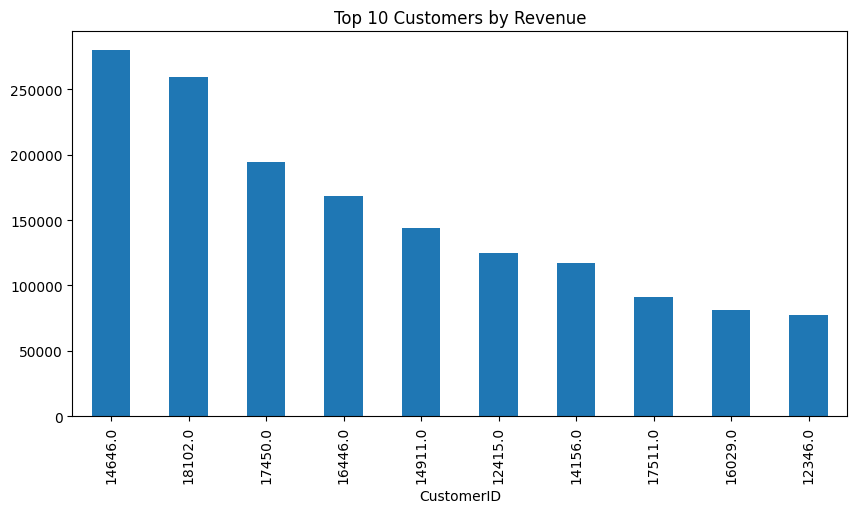

In [21]:
#Top 10 customers
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
#plot diagram for revenue
top_customers.plot(kind='bar',figsize=(10,5),title="Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.show()

In [22]:
share = (top_customers.sum()/df['Revenue'].sum()) * 100
print(share.round(2))

17.26


17% of total revenue makes by top 10 customers;
Offering loyalty program in a right time(like November) is defined by VIP customers.

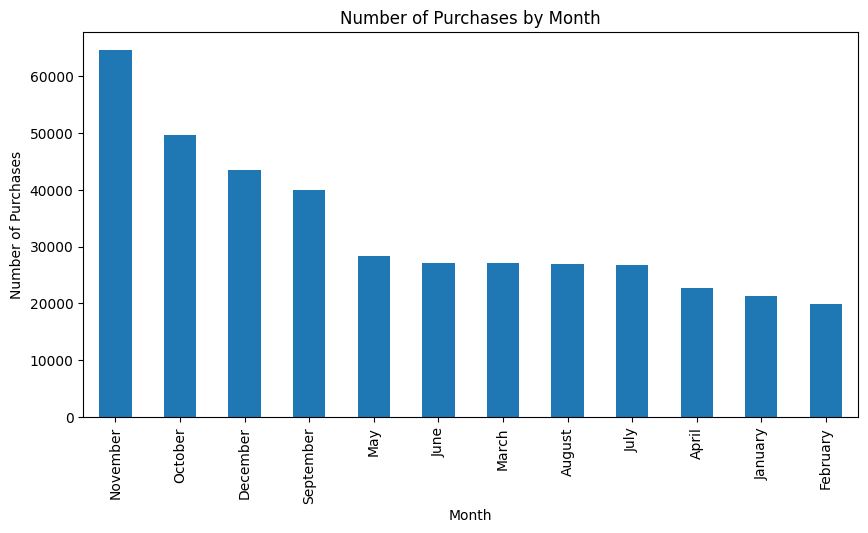

In [23]:
#exctracting month and day from date
df['Month'] = df['InvoiceDate'].dt.month_name()
df['Month'].value_counts().plot(kind='bar', figsize=(10,5), title="Number of Purchases by Month")
plt.ylabel("Number of Purchases")
plt.show()


<Axes: xlabel='Description'>

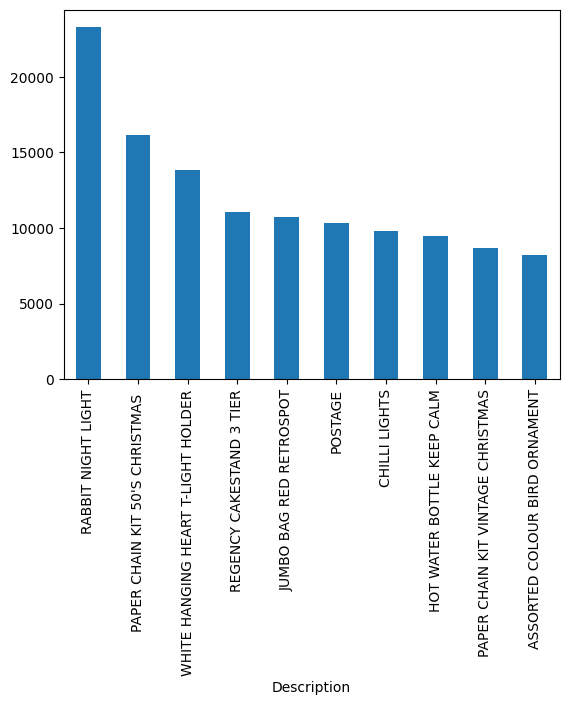

In [24]:
#filter data for most sold in momth
df[df['Month']=='November'].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

November is more shopping activity and highlight seasonal purchasing bahaviour and it is because of holiday shopping and promptional events.
the most top selling products are related to decorative and gift items and it may need to consider for inventory and shipping services.

In [25]:
#the importance of week days
df['DayofWeek'] = df['InvoiceDate'].dt.day_name()
df['DayofWeek'].value_counts()

,count
DayofWeek,
Thursday,80035
Wednesday,68885
Tuesday,66473
Monday,64893
Sunday,62773
Friday,54825


The highest sales can help to identify the pattern in customer purchasing, it is shown that before new year customer prefer to buy more.
additionaly the peak days in a week is Thursday.

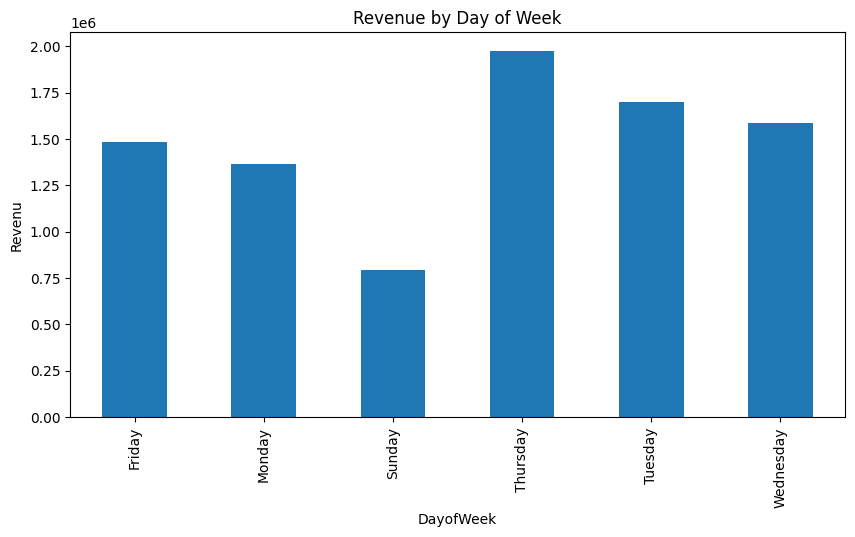

In [26]:
#revenue by week day
salaes_by_day = df.groupby('DayofWeek')['Revenue'].sum()
# Plot
salaes_by_day.plot(kind='bar', figsize=(10,5), title="Revenue by Day of Week")
plt.ylabel("Revenu")
plt.show()



This plot helps to understand customer behaviur across the week and adjust promotion on peak days.

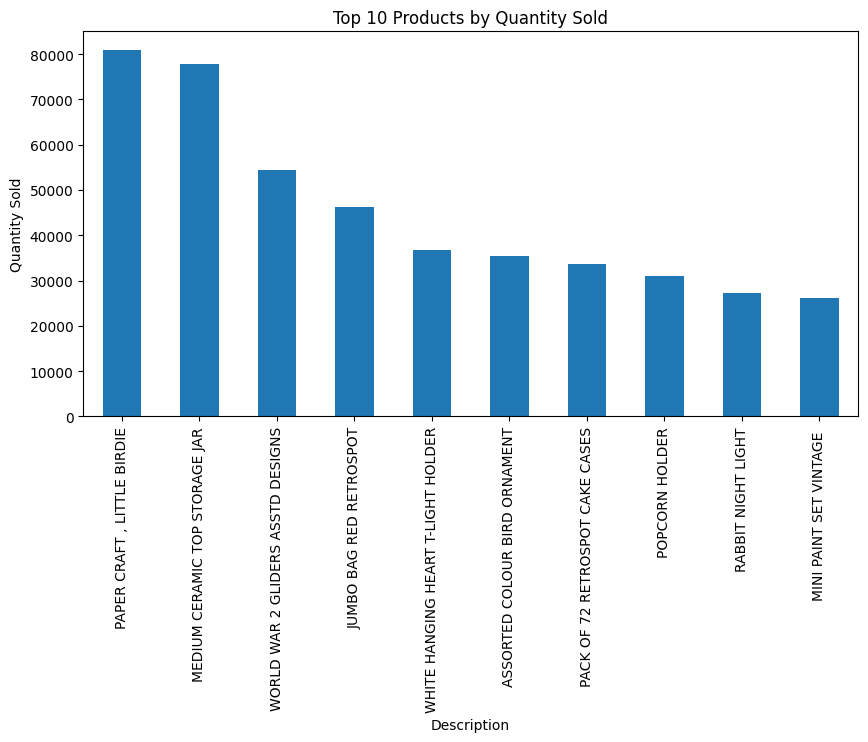

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


In [41]:
#Top Seller products
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
top_products_qty.plot(kind='bar', figsize=(10,5), title="Top 10 Products by Quantity Sold")
plt.ylabel("Quantity Sold")
plt.show()

top_products_qty

In [43]:
share_products = (top_products_qty.sum()/df['Quantity'].sum()) * 100
print(share_products.round(2))

8.7


Identify these top 10 sold products show about 9% of products are more demanded.

<Axes: xlabel='Description'>

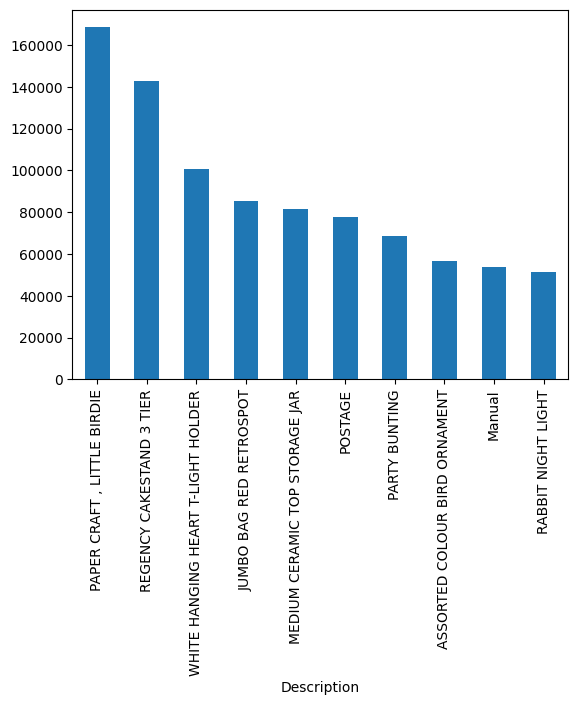

In [ ]:
## most revenue based on products item
most_revenue = df.groupby('Description')['Revenue'].sum()
most_revenue.sort_values(ascending=False).head(10).plot(kind='bar')


In [49]:
#compare revenue regarding price level and quantity and products
comparison = df.groupby('Description').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'UnitPrice': 'mean'
}).sort_values(by='Revenue', ascending=False)

comparison.head(10)

,Quantity,Revenue,UnitPrice
Description,,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2.080000
REGENCY CAKESTAND 3 TIER,12402,142592.95,12.483401
WHITE HANGING HEART T-LIGHT HOLDER,36725,100448.15,2.893107
JUMBO BAG RED RETROSPOT,46181,85220.78,2.015878
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,1.220303
POSTAGE,3120,77803.96,31.570482
PARTY BUNTING,15291,68844.33,4.876375
ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34,1.680795
Manual,7173,53779.93,175.291585


The revenue trend shows that high sales volume does not necesserily lead to higher revenue becuse of low price.
There is some expensive product like Manual, even with low sales it generates strong revenue.
The analysis demonstrates that the low price product attract customers and expensive products maximize the revenue.


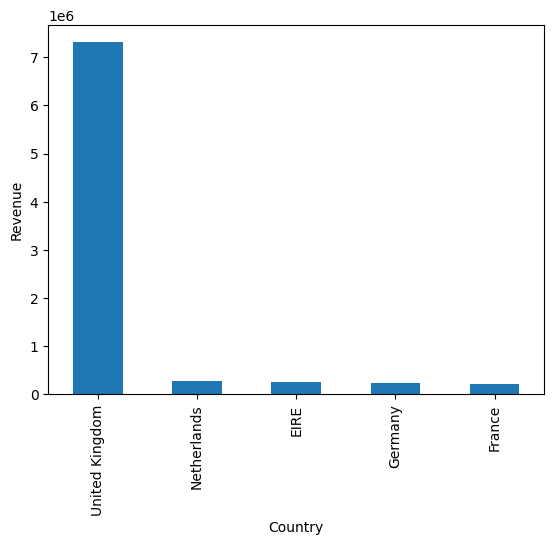

In [ ]:
##countries generate the highest revenue
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5).plot(kind='bar')
plt.ylabel("Revenue")
plt.show()


<Axes: xlabel='Description'>

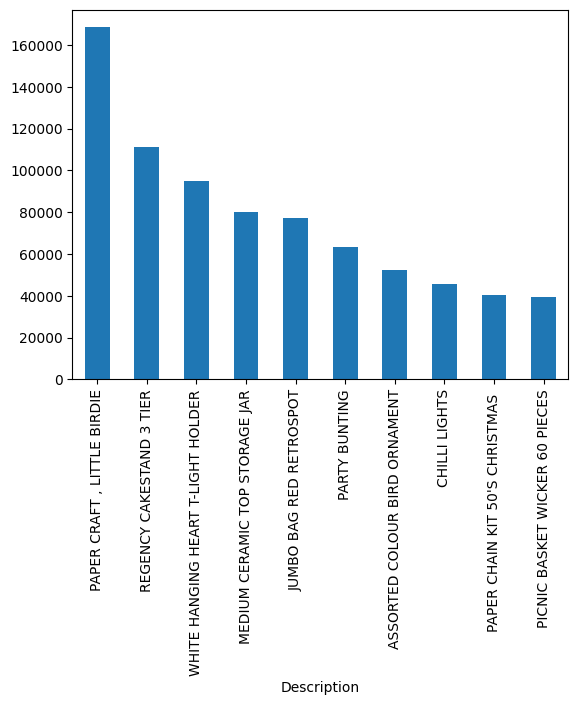

In [30]:
df[df['Country']=='United Kingdom'].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

The analysis shows that the UK is the most country to make revenue and top seller in this country is the same as global trends.

## Conclusion
The analysis provides insights into customers purchasing patterns and can help to identify the seasonal and country top selling items.
The dataset does not include the demoghraphic data and it helps to undrestand the deeper layer of customers to identify the segmentations.Based on revenue in different plots it is possible to create the loyalty programm for high value customers or promote best selling items in peak days in differnt countries.